In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy

# Delays
delaysList = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 4.75]

if "data" not in os.getcwd():
    path = os.path.join(os.path.dirname(os.getcwd()),'data', 'Day2')
    os.chdir(path)


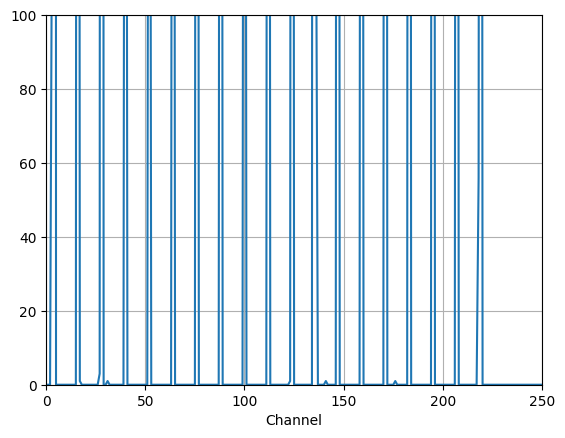

In [2]:

def getRelevantPeaks(data):
    arr = list()
    for i in range(len(data[:,0])):
        # Filter out values that have counts less than 5 (aren't peaks)
        if data[:,1][i] > 5:
            arr.append([data[:,0][i], data[:,1][i]])

    newArr = list()
    # Add the first value since it's excluded in the loop below (3 in our case)
    newArr.append(arr[0][0])

    # Loop through all filtered values and remove points that have consecutive points (e.g. 3 and 4, only 3 remains) since that's also noise
    for i in range(len(arr)):
        if i > 0:
            if abs(arr[i][0] - arr[i - 1][0]) > 1:
                newArr.append(arr[i][0])
    return newArr

fileData = np.loadtxt('chanConversion.txt', dtype='float', delimiter='\t', skiprows=1)
columnTitles = np.loadtxt('chanConversion.txt', dtype='str', delimiter='\t', max_rows=1)

# Save this to a variable
relevantPeaks = getRelevantPeaks(fileData)

plt.xlabel("Channel")
plt.grid()
plt.ylim((0,100))
plt.xlim((0,250))
plt.plot(fileData[:,0],fileData[:,1])


In [16]:
# Linear fitting def
def fitting_funct(xVal, a, b):
    '''Fitting function for the given datapoints'''
    return a * xVal + b

popt, _ = scipy.optimize.curve_fit(fitting_funct, delaysList, relevantPeaks, sigma=1)

# Models, 5% error for delays, 1 error for channels
realData = scipy.odr.RealData(relevantPeaks, 
                              delaysList,
                              sx=[1 for i in range(len(relevantPeaks))], 
                              sy=[0.05 * delaysList[i] for i in range(len(relevantPeaks))])
modelODR = scipy.odr.Model(lambda params, xVal: fitting_funct(xVal, params[0],params[1]))
odr      = scipy.odr.ODR(realData, modelODR, beta0=[0,0])
output   = odr.run()

#print(output.beta)
#print(output.cov_beta)

for i in range(len(output.cov_beta)):
    print(f"Statistical error on parameter {i}: {round(np.sqrt(output.cov_beta[i][i])/(abs(output.beta[i]))*100, 2)}%")

Statistical error on parameter 0: 1.7%
Statistical error on parameter 1: 10.61%


Value of slope      : 0.02061260440682878 +/- 0.012477911788472186
Value of y-intercept: 0.18736270010018582 +/- 0.15941243097940921


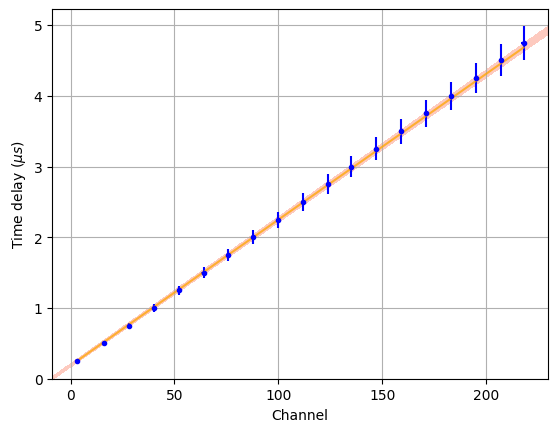

In [15]:
# Plot data and fit

plotRange = np.linspace(min(relevantPeaks), max(relevantPeaks), 1000)

print(rf"Value of slope      : {output.beta[0]} +/- {np.sqrt(output.cov_beta[0][0])}")
print(rf"Value of y-intercept: {output.beta[1]} +/- {np.sqrt(output.cov_beta[1][1])}")

plt.errorbar(relevantPeaks, delaysList, xerr=1, yerr = 0.05*np.array(delaysList), fmt='.', color = 'blue')
plt.plot(plotRange, fitting_funct(plotRange, output.beta[0], output.beta[1]), color = 'orange', alpha = 0.75)


xrange = np.linspace(plt.xlim()[0],plt.xlim()[1], 1000)
yrange = np.linspace(plt.ylim()[0],plt.ylim()[1], 1000)

X, Y = np.meshgrid(xrange, yrange)

Ymin = (output.beta[0]-output.cov_beta[0][0])*X + output.beta[1] - output.cov_beta[1][1]
Ymax = (output.beta[0]+output.cov_beta[0][0])*X + output.beta[1] + output.cov_beta[1][1]

Z = np.logical_and(np.less(Y, Ymax) , np.less(Ymin, Y))

plt.contourf(X ,Y ,Z ,levels = [0.99, 1.01], cmap = 'Reds', alpha = 0.35)

plt.xlabel("Channel")
plt.ylabel(r"Time delay ($\mu s$)")
plt.grid()
plt.show()

In [ ]:
## Save the fitting data to another file as a dictionary
import yaml

paramdict = {'aval': float(output.beta[0]),
             'aerr': float(output.cov_beta[0][0]),
             'bval': float(output.beta[1]),
             'berr': float(output.cov_beta[1][1])}

with open('fitparams.yaml', 'w') as f:
    yaml.dump(paramdict, f)
